# 06 - Graph features avec NetworkX

Objectif : couvrir la partie graphe demandee dans le sujet :

- construire un graphe de 10 000 transactions ;
- noeuds = comptes clients + marchands ;
- aretes = transactions ;
- visualiser le graphe ;
- identifier un cluster suspect ;
- extraire des features graphe ;
- integrer ces features dans XGBoost ;
- commenter le gain d'AUPRC.

Le dataset IEEE-CIS ne contient pas de vrai identifiant client ni marchand. On utilise donc :

- `customer_proxy` = combinaison carte/adresse ;
- `merchant_proxy` = combinaison `ProductCD` + `R_emaildomain`.

C'est une approximation de POC, a documenter dans le rapport.


## 0. Installation et imports

Si besoin :

```bash
pip install polars pyarrow pandas numpy matplotlib seaborn scikit-learn xgboost networkx
```


In [1]:
from pathlib import Path
import gc
import time
import warnings

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
DATA_DIR = Path("data") if Path("data").exists() else Path("../data")
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
ASSETS_DIR = PROJECT_ROOT / "docs" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_TRANSACTION_PATH = DATA_DIR / "train_transaction.csv"
TRAIN_IDENTITY_PATH = DATA_DIR / "train_identity.csv"

for path in [TRAIN_TRANSACTION_PATH, TRAIN_IDENTITY_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable : {path.resolve()}")


def save_plot(filename):
    output_path = ASSETS_DIR / filename
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Figure sauvegardee : {output_path}")


## 1. Configuration

On construit le graphe sur les **10 000 dernieres transactions du train temporel**. Cela donne un sous-graphe proche de la periode de validation, donc plus utile pour comparer avec les performances du modele.


In [2]:
VALID_SIZE = 0.20
GRAPH_N_TRANSACTIONS = 10_000
DECISION_THRESHOLD = 0.25

BASE_XGB_PARAMS = dict(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


## 2. Chargement et features de base

On reconstruit les memes features compactes que dans les notebooks precedents, puis on ajoute les proxys client et marchand necessaires au graphe.


In [3]:
start = time.time()

# On ne charge que les colonnes necessaires. Charger les 434 colonnes peut faire crasher le kernel.
transaction_needed_cols = [
    "TransactionID", "isFraud", "TransactionDT", "TransactionAmt", "ProductCD",
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2", "dist1", "dist2",
    "P_emaildomain", "R_emaildomain",
    "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9", "C10", "C11", "C12", "C13", "C14",
    "D1", "D2", "D3", "D4", "D5", "D10", "D15",
]
identity_needed_cols = [
    "TransactionID", "DeviceType", "id_12", "id_15", "id_16", "id_28", "id_29",
    "id_35", "id_36", "id_37", "id_38",
]

transaction_available_cols = pl.read_csv(TRAIN_TRANSACTION_PATH, n_rows=0).columns
identity_available_cols = pl.read_csv(TRAIN_IDENTITY_PATH, n_rows=0).columns
transaction_cols = [col for col in transaction_needed_cols if col in transaction_available_cols]
identity_cols = [col for col in identity_needed_cols if col in identity_available_cols]

train = (
    pl.scan_csv(TRAIN_TRANSACTION_PATH)
    .select(transaction_cols)
    .join(pl.scan_csv(TRAIN_IDENTITY_PATH).select(identity_cols), on="TransactionID", how="left")
    .sort("TransactionDT")
    .collect()
)

SECONDS_PER_HOUR = 3600
SECONDS_PER_DAY = 24 * SECONDS_PER_HOUR
SECONDS_PER_WEEK = 7 * SECONDS_PER_DAY

train = train.with_columns([
    (pl.col("TransactionDT") // SECONDS_PER_HOUR).cast(pl.Int64).alias("hour_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_DAY).cast(pl.Int64).alias("day_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_WEEK).cast(pl.Int64).alias("week_rel"),
    ((pl.col("TransactionDT") // SECONDS_PER_HOUR) % 24).cast(pl.Int64).alias("hour_of_day_rel"),
])

id_cols = [col for col in ["card1", "card2", "card3", "card5", "addr1"] if col in train.columns]
merchant_cols = [col for col in ["ProductCD", "R_emaildomain"] if col in train.columns]

train = (
    train
    .with_row_count("txn_row_id")
    .with_columns([
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in id_cols], separator="_").alias("customer_proxy"),
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in merchant_cols], separator="_").alias("merchant_proxy"),
    ])
    .sort(["customer_proxy", "TransactionDT", "txn_row_id"])
    .with_columns([
        pl.cum_count("TransactionID").over("customer_proxy").sub(1).alias("customer_tx_count_prev"),
        pl.col("TransactionAmt").cum_sum().shift(1).over("customer_proxy").alias("customer_amt_sum_prev"),
        pl.cum_count("TransactionID").over(["customer_proxy", "merchant_proxy"]).sub(1).alias("merchant_seen_count_prev"),
    ])
    .with_columns([
        pl.when(pl.col("customer_tx_count_prev") > 0)
        .then(pl.col("customer_amt_sum_prev") / pl.col("customer_tx_count_prev"))
        .otherwise(None)
        .alias("customer_amt_mean_prev"),
        pl.when(pl.col("customer_tx_count_prev") > 0)
        .then(pl.col("TransactionAmt") / (pl.col("customer_amt_sum_prev") / pl.col("customer_tx_count_prev")))
        .otherwise(None)
        .alias("amt_to_customer_mean_prev"),
        (pl.col("merchant_seen_count_prev") == 0).cast(pl.Int8).alias("is_new_merchant_for_customer"),
    ])
    .sort("txn_row_id")
)

print(f"Dataset charge et enrichi : {train.shape}")
print(f"Temps : {time.time() - start:.1f} secondes")


Dataset charge et enrichi : (590540, 61)
Temps : 149.9 secondes


## 3. Construction du graphe de 10 000 transactions

Le graphe est biparti :

- noeuds client : `CUST::<customer_proxy>` ;
- noeuds marchand : `MERCH::<merchant_proxy>` ;
- aretes : transactions entre client et marchand.


In [4]:
split_idx = int(train.height * (1 - VALID_SIZE))
graph_start = max(0, split_idx - GRAPH_N_TRANSACTIONS)

graph_pl = train.slice(graph_start, GRAPH_N_TRANSACTIONS).select([
    "TransactionID", "isFraud", "TransactionDT", "day_rel", "TransactionAmt",
    "customer_proxy", "merchant_proxy",
]).sort("TransactionDT")

graph_df = graph_pl.to_pandas()
graph_df["customer_node"] = "CUST::" + graph_df["customer_proxy"].astype(str)
graph_df["merchant_node"] = "MERCH::" + graph_df["merchant_proxy"].astype(str)

G = nx.Graph()
for row in graph_df.itertuples(index=False):
    G.add_node(row.customer_node, node_type="customer")
    G.add_node(row.merchant_node, node_type="merchant")
    if G.has_edge(row.customer_node, row.merchant_node):
        G[row.customer_node][row.merchant_node]["weight"] += 1
        G[row.customer_node][row.merchant_node]["amount_sum"] += float(row.TransactionAmt)
        G[row.customer_node][row.merchant_node]["fraud_count"] += int(row.isFraud)
    else:
        G.add_edge(
            row.customer_node,
            row.merchant_node,
            weight=1,
            amount_sum=float(row.TransactionAmt),
            fraud_count=int(row.isFraud),
        )

print(f"Transactions graphe : {len(graph_df)}")
print(f"Noeuds : {G.number_of_nodes()}")
print(f"Aretes : {G.number_of_edges()}")
print(f"Composantes connexes : {nx.number_connected_components(G)}")
print(f"Taux de fraude sous-graphe : {graph_df['isFraud'].mean():.4%}")


Transactions graphe : 10000
Noeuds : 4119
Aretes : 4501
Composantes connexes : 14
Taux de fraude sous-graphe : 3.1200%


## 4. Visualisation et cluster suspect

On visualise la plus grande composante connexe pour rendre le graphe lisible. Les noeuds rouges sont lies a au moins une transaction frauduleuse.


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/06_graph_networkx_visualization.png


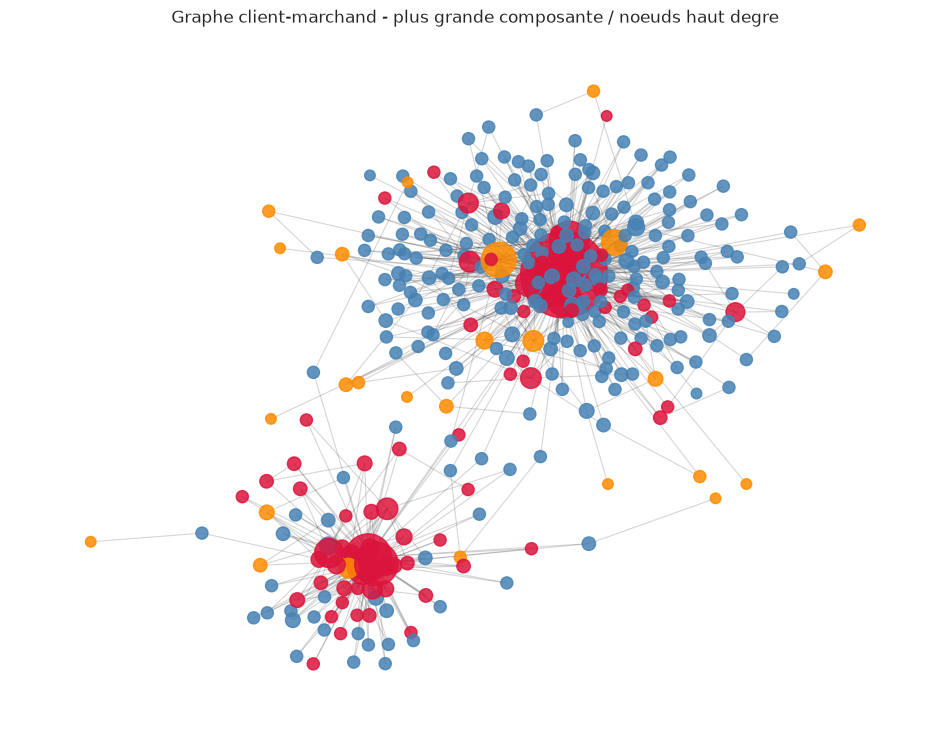

In [5]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
largest_component_nodes = components[0]
G_largest = G.subgraph(largest_component_nodes).copy()

# Si la composante est trop grande, on limite aux noeuds de plus haut degre pour un plot lisible.
MAX_PLOT_NODES = 350
if G_largest.number_of_nodes() > MAX_PLOT_NODES:
    top_nodes = sorted(G_largest.degree, key=lambda x: x[1], reverse=True)[:MAX_PLOT_NODES]
    top_nodes = [node for node, degree in top_nodes]
    G_plot = G_largest.subgraph(top_nodes).copy()
else:
    G_plot = G_largest

fraud_nodes = set()
for u, v, data in G.edges(data=True):
    if data.get("fraud_count", 0) > 0:
        fraud_nodes.add(u)
        fraud_nodes.add(v)

node_colors = []
node_sizes = []
for node in G_plot.nodes:
    if node in fraud_nodes:
        node_colors.append("crimson")
    elif node.startswith("MERCH::"):
        node_colors.append("darkorange")
    else:
        node_colors.append("steelblue")
    node_sizes.append(40 + 18 * G_plot.degree[node])

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G_plot, seed=RANDOM_STATE, k=0.25)
nx.draw_networkx_edges(G_plot, pos, alpha=0.18, width=0.8)
nx.draw_networkx_nodes(G_plot, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)
plt.title("Graphe client-marchand - plus grande composante / noeuds haut degre")
plt.axis("off")
save_plot("06_graph_networkx_visualization.png")
plt.show()


In [6]:
component_rows = []
for comp_id, nodes in enumerate(components[:50]):
    sub = G.subgraph(nodes)
    edge_frauds = sum(data.get("fraud_count", 0) for _, _, data in sub.edges(data=True))
    edge_count = sub.number_of_edges()
    amount_sum = sum(data.get("amount_sum", 0.0) for _, _, data in sub.edges(data=True))
    component_rows.append({
        "component_id": comp_id,
        "nodes": sub.number_of_nodes(),
        "edges": edge_count,
        "fraud_edges": edge_frauds,
        "fraud_edge_rate": edge_frauds / edge_count if edge_count else 0,
        "amount_sum": amount_sum,
    })

components_df = pd.DataFrame(component_rows).sort_values(
    ["fraud_edge_rate", "fraud_edges", "edges"], ascending=False
).reset_index(drop=True)
display(components_df.head(10))

suspect_component_id = int(components_df.iloc[0]["component_id"])
suspect_nodes = components[suspect_component_id]
print(f"Cluster suspect retenu : composante {suspect_component_id}")


,component_id,nodes,edges,fraud_edges,fraud_edge_rate,amount_sum
0,8,2,1,1,1.0000,325.0000
1,0,4088,4483,311,0.0694,"1,396,263.7650"
2,1,4,3,0,0.0000,150.2560
3,2,4,3,0,0.0000,265.9000
4,3,3,2,0,0.0000,200.0000
5,4,2,1,0,0.0000,55.5160
6,5,2,1,0,0.0000,150.0000
7,6,2,1,0,0.0000,50.0000
8,7,2,1,0,0.0000,250.0000
9,9,2,1,0,0.0000,30.0000


Cluster suspect retenu : composante 8


### 4 bis. Zoom sur un cluster suspect

La table precedente peut selectionner une composante tres petite avec un taux de fraude eleve. Pour une lecture visuelle plus utile, on retient ici une composante suspecte non triviale : on privilegie les composantes avec plusieurs aretes frauduleuses, puis le taux de fraude et le volume.


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/06_graph_suspect_cluster_zoom.png


,cluster_suspect_visuel
component_id,0.0000
nodes,"4,088.0000"
edges,"4,483.0000"
fraud_edges,311.0000
fraud_edge_rate,0.0694
amount_sum,"1,396,263.7650"


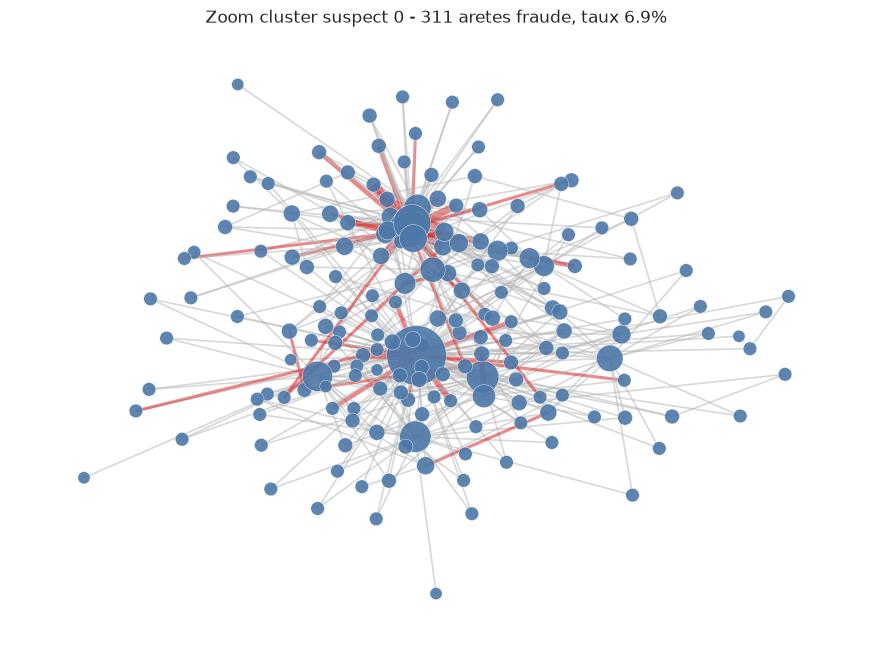

In [7]:
candidate_components = components_df.copy()
# On evite de retenir uniquement un couple client-marchand isole si un cluster plus large contient plusieurs fraudes.
non_trivial = candidate_components[candidate_components["fraud_edges"] >= 3]
if len(non_trivial) == 0:
    non_trivial = candidate_components[candidate_components["fraud_edges"] > 0]

visual_suspect = (
    non_trivial
    .sort_values(["fraud_edges", "fraud_edge_rate", "amount_sum"], ascending=[False, False, False])
    .iloc[0]
)
visual_suspect_component_id = int(visual_suspect["component_id"])
visual_suspect_nodes = components[visual_suspect_component_id]
G_suspect_full = G.subgraph(visual_suspect_nodes).copy()

# Pour garder le zoom lisible, on affiche les noeuds lies a des fraudes et leurs voisins directs.
fraud_related_nodes = set()
for u, v, data in G_suspect_full.edges(data=True):
    if data.get("fraud_count", 0) > 0:
        fraud_related_nodes.update([u, v])
        fraud_related_nodes.update(G_suspect_full.neighbors(u))
        fraud_related_nodes.update(G_suspect_full.neighbors(v))

if len(fraud_related_nodes) == 0:
    fraud_related_nodes = set(G_suspect_full.nodes())

if len(fraud_related_nodes) > 180:
    fraud_related_nodes = set(
        sorted(fraud_related_nodes, key=lambda n: G_suspect_full.degree(n), reverse=True)[:180]
    )

G_suspect = G_suspect_full.subgraph(fraud_related_nodes).copy()
pos = nx.spring_layout(G_suspect, seed=RANDOM_STATE, k=0.35)
node_colors = ["#d62728" if G_suspect.nodes[n].get("fraud_touch", 0) else "#4c78a8" for n in G_suspect.nodes()]
node_sizes = [60 + 18 * G_suspect.degree(n) for n in G_suspect.nodes()]
edge_colors = ["#d62728" if data.get("fraud_count", 0) > 0 else "#b8b8b8" for _, _, data in G_suspect.edges(data=True)]
edge_widths = [1.2 + data.get("fraud_count", 0) for _, _, data in G_suspect.edges(data=True)]

plt.figure(figsize=(11, 8))
nx.draw_networkx_edges(G_suspect, pos, edge_color=edge_colors, width=edge_widths, alpha=0.55)
nx.draw_networkx_nodes(G_suspect, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, linewidths=0.3, edgecolors="white")
plt.title(
    f"Zoom cluster suspect {visual_suspect_component_id} - "
    f"{int(visual_suspect['fraud_edges'])} aretes fraude, "
    f"taux {visual_suspect['fraud_edge_rate']:.1%}"
)
plt.axis("off")
save_plot("06_graph_suspect_cluster_zoom.png")

visual_suspect_summary = visual_suspect.to_dict()
display(pd.Series(visual_suspect_summary).to_frame("cluster_suspect_visuel"))


## 5. Extraction des features graphe

Features demandees :

- degre du noeud compte ;
- nombre de marchands distincts sur 7 jours ;
- centralite betweenness.

La centralite est calculee sur le graphe de 10 000 transactions. Elle est ensuite jointe aux transactions via `customer_proxy`.


In [8]:
degree_dict = dict(G.degree())
weighted_degree_dict = dict(G.degree(weight="weight"))
print("Calcul betweenness centrality...")
start = time.time()
betweenness_dict = nx.betweenness_centrality(G, k=min(500, G.number_of_nodes()), seed=RANDOM_STATE, normalized=True)
print(f"Betweenness calculee en {time.time() - start:.1f} secondes")

customer_graph_features = []
for customer_node in [n for n, d in G.nodes(data=True) if d.get("node_type") == "customer"]:
    customer_proxy = customer_node.replace("CUST::", "", 1)
    customer_graph_features.append({
        "customer_proxy": customer_proxy,
        "graph_customer_degree": degree_dict.get(customer_node, 0),
        "graph_customer_weighted_degree": weighted_degree_dict.get(customer_node, 0),
        "graph_customer_betweenness": betweenness_dict.get(customer_node, 0.0),
    })

graph_features_df = pd.DataFrame(customer_graph_features)

# Calcul exact mais simple sur 10 000 lignes : nombre de marchands distincts dans les 7 jours precedents.
graph_df = graph_df.sort_values("TransactionDT").reset_index(drop=True)
merchant_7d = []
for row in graph_df.itertuples():
    start_dt = row.TransactionDT - 7 * 24 * 3600
    hist = graph_df[
        (graph_df["customer_proxy"] == row.customer_proxy)
        & (graph_df["TransactionDT"] < row.TransactionDT)
        & (graph_df["TransactionDT"] >= start_dt)
    ]
    merchant_7d.append(hist["merchant_proxy"].nunique())
graph_df["graph_distinct_merchants_prev_7d"] = merchant_7d

graph_features_tx = graph_df[["TransactionID", "customer_proxy", "graph_distinct_merchants_prev_7d"]].merge(
    graph_features_df,
    on="customer_proxy",
    how="left",
)
graph_features_tx = graph_features_tx.drop(columns=["customer_proxy"])

display(graph_features_tx.head())
display(graph_features_tx.describe())


Calcul betweenness centrality...
Betweenness calculee en 13.8 secondes


,TransactionID,graph_distinct_merchants_prev_7d,graph_customer_degree,graph_customer_weighted_degree,graph_customer_betweenness
0,3449432,0,1,12,0.0000
1,3449433,0,1,1,0.0000
2,3449434,0,1,10,0.0000
3,3449435,0,2,4,0.0006
4,3449436,0,4,83,0.0022


,TransactionID,graph_distinct_merchants_prev_7d,graph_customer_degree,graph_customer_weighted_degree,graph_customer_betweenness
count,"10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000"
mean,"3,454,431.5000",0.9360,1.6747,14.4822,0.0004
std,"2,886.8957",1.2167,1.4467,27.1014,0.0018
min,"3,449,432.0000",0.0000,1.0000,1.0000,0.0000
25%,"3,451,931.7500",0.0000,1.0000,1.0000,0.0000
50%,"3,454,431.5000",1.0000,1.0000,4.0000,0.0000
75%,"3,456,931.2500",1.0000,2.0000,12.0000,0.0002
max,"3,459,431.0000",8.0000,8.0000,143.0000,0.0476


## 6. Comparaison XGBoost sans / avec graph features

Pour mesurer le gain, on entraine sur le debut du sous-graphe et on valide sur la fin du sous-graphe, en gardant un split temporel local.


In [9]:
base_feature_candidates = [
    "TransactionAmt",
    "card1", "card2", "card3", "card5",
    "addr1", "addr2", "dist1", "dist2",
    "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9", "C10", "C11", "C12", "C13", "C14",
    "D1", "D2", "D3", "D4", "D5", "D10", "D15",
    "hour_rel", "day_rel", "week_rel", "hour_of_day_rel",
    "ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain", "DeviceType",
    "customer_tx_count_prev", "customer_amt_mean_prev", "amt_to_customer_mean_prev", "is_new_merchant_for_customer",
]
base_feature_cols = [col for col in base_feature_candidates if col in train.columns]

graph_feature_cols = [
    "graph_customer_degree",
    "graph_customer_weighted_degree",
    "graph_customer_betweenness",
    "graph_distinct_merchants_prev_7d",
]

model_graph_pd = train.select(list(dict.fromkeys(base_feature_cols + ["TransactionID", "isFraud", "day_rel"]))).to_pandas()
model_graph_pd = model_graph_pd.merge(graph_features_tx, on="TransactionID", how="inner")
model_graph_pd[graph_feature_cols] = model_graph_pd[graph_feature_cols].fillna(0)
model_graph_pd = model_graph_pd.sort_values("day_rel").reset_index(drop=True)

split_local = int(len(model_graph_pd) * 0.8)
train_local = model_graph_pd.iloc[:split_local].copy()
valid_local = model_graph_pd.iloc[split_local:].copy()

print(f"Dataset local graphe : {model_graph_pd.shape}")
print(f"Train local : {train_local.shape}, valid local : {valid_local.shape}")
print(f"Taux fraude valid local : {valid_local['isFraud'].mean():.4%}")


Dataset local graphe : (10000, 50)
Train local : (8000, 50), valid local : (2000, 50)
Taux fraude valid local : 3.8500%


In [10]:
def train_eval_feature_set(feature_set_name, feature_list):
    X_tr = train_local[feature_list]
    y_tr = train_local["isFraud"].astype(int)
    X_val = valid_local[feature_list]
    y_val = valid_local["isFraud"].astype(int)

    numeric_cols = X_tr.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [col for col in feature_list if col not in numeric_cols]

    preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ]), categorical_cols),
        ],
        remainder="drop",
    )

    X_tr_p = preprocess.fit_transform(X_tr)
    X_val_p = preprocess.transform(X_val)

    model = XGBClassifier(**BASE_XGB_PARAMS)
    start = time.time()
    model.fit(X_tr_p, y_tr.to_numpy())
    train_time = time.time() - start

    scores = model.predict_proba(X_val_p)[:, 1]
    preds = (scores >= DECISION_THRESHOLD).astype(int)
    return {
        "feature_set": feature_set_name,
        "n_features": len(feature_list),
        "AUPRC": average_precision_score(y_val, scores),
        "precision": precision_score(y_val, preds, zero_division=0),
        "recall": recall_score(y_val, preds, zero_division=0),
        "F1": f1_score(y_val, preds, zero_division=0),
        "alert_rate": preds.mean(),
        "train_time_sec": train_time,
    }, scores

base_result, base_scores = train_eval_feature_set("xgboost_base", base_feature_cols)
graph_result, graph_scores = train_eval_feature_set("xgboost_base_plus_graph", base_feature_cols + graph_feature_cols)

comparison_df = pd.DataFrame([base_result, graph_result])
comparison_df["AUPRC_gain_vs_base"] = comparison_df["AUPRC"] - comparison_df.loc[0, "AUPRC"]
display(comparison_df)

comparison_path = PROJECT_ROOT / "docs" / "graph_features_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"Comparaison sauvegardee : {comparison_path}")


,feature_set,n_features,AUPRC,precision,recall,F1,alert_rate,train_time_sec,AUPRC_gain_vs_base
0,xgboost_base,44,0.5570,0.7551,0.4805,0.5873,0.0245,1.8581,0.0000
1,xgboost_base_plus_graph,48,0.6096,0.7358,0.5065,0.6000,0.0265,1.4629,0.0526


Comparaison sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/graph_features_comparison.csv


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/06_graph_features_model_comparison.png


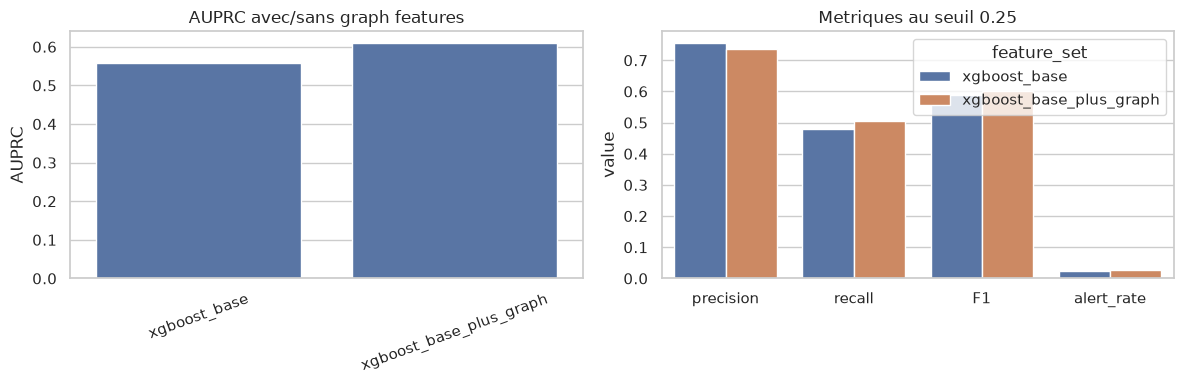

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=comparison_df, x="feature_set", y="AUPRC", ax=axes[0])
axes[0].set_title("AUPRC avec/sans graph features")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

plot_df = comparison_df.melt(id_vars="feature_set", value_vars=["precision", "recall", "F1", "alert_rate"])
sns.barplot(data=plot_df, x="variable", y="value", hue="feature_set", ax=axes[1])
axes[1].set_title("Metriques au seuil 0.25")
axes[1].set_xlabel("")
plt.tight_layout()
save_plot("06_graph_features_model_comparison.png")
plt.show()


## 7. Conclusion

A completer apres execution :

- decrire le cluster suspect identifie ;
- commenter le role du degre et de la centralite ;
- comparer l'AUPRC avec et sans graph features ;
- conclure si les features graphe ameliorent le modele sur ce sous-ensemble.
